<a href="https://colab.research.google.com/github/m2agrawal-creator/GitExercise_Conflicts/blob/main/cogs108.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('online_shoppers_intention.csv')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'online_shoppers_intention.csv'

The dataset was obtained from the UCI Machine Learning Repository and contains session-level browsing data for an e-commerce website. Each row represents a user session and includes behavioral metrics such as page visits, time spent on pages, and contextual features such as month, weekend indicator, and visitor type.

In [ ]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

The dataset contains 12,330 browsing sessions and 18 variables. These include browsing behavior features such as page visits and durations, contextual variables such as month and weekend indicator, and the target variable Revenue which indicates whether the session resulted in a purchase.

### Tidy Data Check

The dataset is already in tidy format:
- Each row represents a single browsing session
- Each column represents one variable describing that session

Therefore no reshaping (pivoting or melting) was required.

###Summary Stasistics

In [ ]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


Summary statistics were examined to understand the distributions of the variables and to identify any potential irregularities in the data.

Text(0.5, 1.0, 'Outlier Check for Product Page Duration')

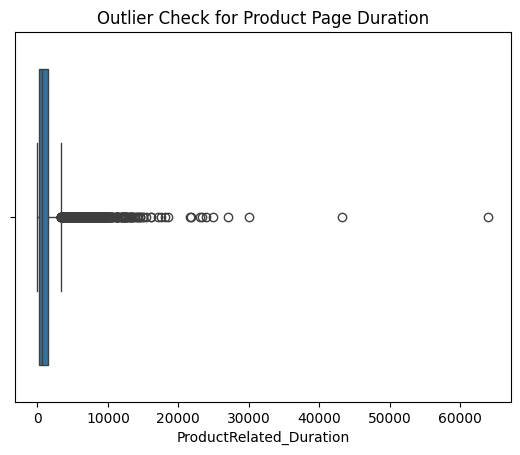

In [ ]:
sns.boxplot(x=df['ProductRelated_Duration'])
plt.title("Outlier Check for Product Page Duration")

We inspected distributions and boxplots to identify potential outliers.  
Some sessions show extremely long browsing durations, which may represent high-engagement sessions rather than data errors.

## Data Wrangling

###Missing Values

We checked for missing values using df.isnull().sum(). No missing values were found in the dataset, meaning no imputation or removal was required.

###Duplicate Rows

In [ ]:
df.duplicated().sum()

np.int64(125)

In [ ]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

The dataset contained 125 duplicate rows.  
These duplicates were removed to ensure each observation represents a unique browsing session.

###Convert Boolean Variables

In [ ]:
df['Revenue'] = df['Revenue'].astype(int)
df['Weekend'] = df['Weekend'].astype(int)

Boolean variables were converted to numeric format to make them easier to use in analysis and modeling.

### Categorical Variables

In [ ]:
categorical_cols = [
    'Month',
    'VisitorType',
    'OperatingSystems',
    'Browser',
    'Region',
    'TrafficType'
]

df[categorical_cols] = df[categorical_cols].astype('category')

Categorical variables were explicitly converted to category data types so they can be handled appropriately during analysis.

###Target Variable Distribution

Text(0.5, 1.0, 'Purchase vs Non-Purchase Sessions')

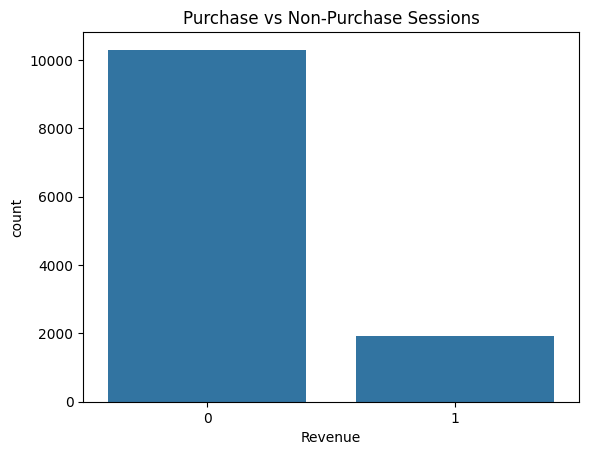

In [ ]:
sns.countplot(x='Revenue', data=df)
plt.title("Purchase vs Non-Purchase Sessions")

The dataset shows a strong imbalance between purchase and non-purchase sessions. This reflects realistic ecommerce behavior where only a small percentage of browsing sessions lead to purchases.

###Feature Distribution Example

Text(0.5, 1.0, 'Distribution of Product Page Visits')

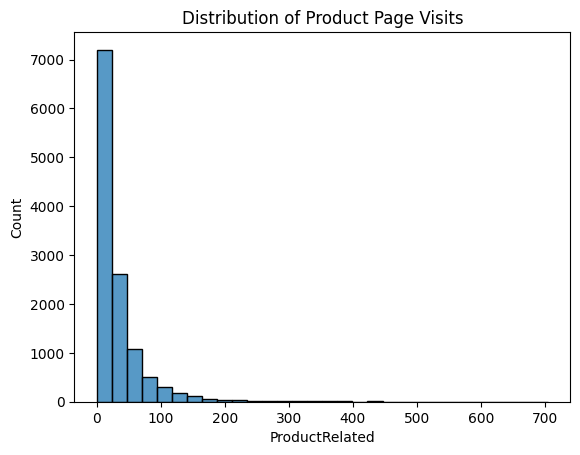

In [ ]:
sns.histplot(df['ProductRelated'], bins=30)
plt.title("Distribution of Product Page Visits")

Most users visit only a small number of product pages, while a smaller number of sessions involve very high product engagement.

###Derived Features

In [ ]:
df['TotalPagesVisited'] = (
    df['Administrative'] +
    df['Informational'] +
    df['ProductRelated']
)

df['TotalDuration'] = (
    df['Administrative_Duration'] +
    df['Informational_Duration'] +
    df['ProductRelated_Duration']
)

Two derived features were created to better capture user engagement during browsing sessions. TotalPagesVisited represents the overall number of pages visited during a session, while TotalDuration represents the total browsing time across different page types.

###Data relevance

In [ ]:
df.groupby("VisitorType")["Revenue"].mean()

/tmp/ipykernel_166/2603719985.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("VisitorType")["Revenue"].mean()


,Revenue
VisitorType,
New_Visitor,0.249262
Other,0.197531
Returning_Visitor,0.140926


Returning visitors appear to have higher purchase probabilities compared to new visitors, suggesting visitor familiarity may influence purchase behavior.

## Final Dataset Check

In [ ]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 12205 entries, 0 to 12329
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Administrative           12205 non-null  int64   
 1   Administrative_Duration  12205 non-null  float64 
 2   Informational            12205 non-null  int64   
 3   Informational_Duration   12205 non-null  float64 
 4   ProductRelated           12205 non-null  int64   
 5   ProductRelated_Duration  12205 non-null  float64 
 6   BounceRates              12205 non-null  float64 
 7   ExitRates                12205 non-null  float64 
 8   PageValues               12205 non-null  float64 
 9   SpecialDay               12205 non-null  float64 
 10  Month                    12205 non-null  category
 11  OperatingSystems         12205 non-null  category
 12  Browser                  12205 non-null  category
 13  Region                   12205 non-null  category
 14  TrafficType

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,TotalPagesVisited,TotalDuration
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,0,0,1,0.000000
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,0,0,2,64.000000
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,0,0,1,0.000000
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,0,0,2,2.666667
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,1,0,10,627.500000


After preprocessing, the dataset contains consistent data types, no missing values, and unique browsing sessions. The data is now ready for exploratory analysis and modeling.

### Dataset Limitations

This dataset represents browsing sessions from a single e-commerce platform, which may limit the generalizability of results to other websites. Additionally, the dataset does not include demographic information about users.

### Saving Clean Dataset

The cleaned dataset was saved to the processed data folder to ensure reproducibility for later analysis steps.

In [ ]:
import os

os.makedirs("data/02-processed", exist_ok=True)

In [ ]:
df.to_csv("data/02-processed/online_shoppers_cleaned.csv", index=False)